### **Code used to generate plots in Fig. 1 and Extended Data Fig. 1**

##### This notebook provides an example of the code used to generate plots found in Fig.1 and Extended Data Fig. 1.

#### **Overview:**

1. Activity quantification with STARR-FISH package
2. Fig. 1 panels
3. Extended Data Fig. 1 panels

#### **Key outputs:**
- Plots portraying transcript per cell counts
- Various correlations between STARR-FISH counts and sequencing counts, or STARR-FISH vs STARR-seq
- Plots of downsampling results for STARR-FISH activity measurements

#### **1. Activity quantification with STARR-FISH package**

##### *General variables and color dictionary used*

In [ ]:
import pandas as pd

colors = {'CRE001' : '#f77189',
        'CRE002' : '#f7755d',
        'CRE003' : '#e68332',
        'CRE004' : '#ce9032',
        'CRE005' : '#bb9832',
        'CRE006' : '#aa9e31',
        'CRE007' : '#97a431',
        'CRE008' : '#7eaa31',
        'CRE009' : '#50b131',
        'CRE010' : '#32b166',
        'CRE011' : '#34af84',
        'CRE012' : '#35ae96',
        'CRE013' : '#36ada4',
        'CRE014' : '#37abb1',
        'CRE015' : '#38aabf',
        'CRE016' : '#39a7d0',
        'CRE017' : '#3ba3ec',
        'CRE018' : '#7a98f4',
        'CRE019' : '#a48cf4',
        'CRE020' : '#c67df4',
        'blank1' : '#e866f4',
        'blank2' : '#f561dd',
        'blank3' : '#f668c2',
        'blank4' : '#f66ca8'}

CREs = ['CRE001', 'CRE002', 'CRE003', 'CRE004', 'CRE005', 'CRE006', 'CRE007', 'CRE008',
        'CRE009', 'CRE010', 'CRE011', 'CRE012', 'CRE013', 'CRE014', 'CRE015', 'CRE016',
        'CRE017', 'CRE018', 'CRE019', 'CRE020']

enhancers = ['E01', 'E02', 'E03', 'E04', 'E05', 'E06', 'E07', 'E08',
        'E09', 'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16',
        'E17', 'E18', 'E19', 'E20']

test_CREs = [0,11,4,7,9,137,186,323,515,642,1100,1086,1078,1073,1093,1101,1102,1103,1104,1105]

STARRseq = pd.read_csv(r'C:\Users\zgibbs\analysis\zgibbs_local\RNAvsDNA.edgeR.csv')
a = STARRseq['genes'].loc[test_CREs]

CRE_names = dict(zip(CREs, a))
enhancer_names = dict(zip(CREs, enhancers))

##### *Import packages*

In [22]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy
import warnings
warnings.filterwarnings('ignore')

##### *Define functions*

In [155]:
def preprocess_experiment(enhancer_file, vector_file, rna_seq_file=None, dna_seq_file=None):
    enhancer = pd.read_csv(enhancer_file)
    vector = pd.read_csv(vector_file)
    enhancer.index = enhancer['masks'].astype(str) + '_' + enhancer['fov'].astype(str)
    vector.index = vector['masks'].astype(str) + '_' + vector['fov'].astype(str)
    # find common index and filter
    common_index = enhancer.index.intersection(vector.index)
    enhancer = enhancer.loc[common_index]
    vector = vector.loc[common_index]
    # drop mask and fov columns
    enhancer_drop = enhancer.copy().drop(columns=['masks', 'fov'])
    vector_drop = vector.copy().drop(columns=['masks', 'fov'])
    result = {"enhancer": enhancer_drop, "vector": vector_drop,
              "enhancer_orig": enhancer, "vector_orig": vector}
    result['enhancer_orig'].rename(columns={'total transcripts': 'total_transcripts'}, inplace=True)
    result['vector_orig'].rename(columns={'total transcripts': 'total_transcripts'}, inplace=True)
    # if rna_seq_file and dna_seq_file are provided, add them to the result
    if rna_seq_file is not None:
        rna_counts = pd.read_csv(rna_seq_file, sep='\t', skipinitialspace=True, skiprows=1)
        rna_counts.set_index('Geneid', inplace=True)
        result['rna_counts'] = rna_counts.iloc[:, -1]
    if dna_seq_file is not None:
        dna_counts = pd.read_csv(dna_seq_file, sep='\t', skipinitialspace=True, skiprows=1)
        dna_counts.set_index('Geneid', inplace=True)
        result['dna_counts'] = dna_counts.iloc[:, -1]
    return result

# glm fit on single experiment, fit enhancer ~ T7
# if norm_by_total, then fit enhancer / total_enhancer ~ vector / total_vector
def glm_fit(experiment, family=sm.families.Gaussian(), use_fov_covariate=True, norm_by_total=False):
    # Create the model
    enhancer = experiment["enhancer"]
    vector = experiment["vector"]
    result = pd.DataFrame()
    if norm_by_total:
        enhancer = enhancer.div(enhancer.iloc[:, -1], axis=0)
        vector = vector.div(vector.iloc[:, -1], axis=0)
    for cre in enhancer.columns[:-1]:
        if cre not in vector.columns:
            raise ValueError(f"CRE {cre} not found in vector data.")
        fit_data=pd.DataFrame({'y': enhancer[cre].values, 
                               'x': vector[cre].values,
                               'fov': experiment["enhancer_orig"]['fov'].values})
        if not use_fov_covariate:
            glm_results = smf.ols('y ~ x', fit_data, family=family).fit()
        else:
            glm_results = smf.ols('y ~ x + C(fov)', fit_data, family=family).fit()
        # Fit the model
        glm_summary = pd.read_html(glm_results.summary().tables[1].as_html(), header=0, index_col=0)[0]
        glm_summary = pd.DataFrame(glm_summary.loc['x']).T
        glm_summary.index = [cre]
        result = pd.concat([result, glm_summary], axis=0)
    # do glm fit on poshen data
    poshen = pd.read_excel(r'C:\Users\zgibbs\analysis\zgibbs_local\STARR-seq_Chen_et_al\Poshen_Table_S3.xlsx', sheet_name = "raw counts HCT116")
    poshen['Activity'] = poshen.iloc[:,-3:].mean(axis=1) / poshen.iloc[:,-4]
    poshen.set_index('oligo', inplace=True)
    poshen_deseq2 = pd.read_csv(r'C:\Users\zgibbs\analysis\zgibbs_local\STARR-seq_Chen_et_al\HCT116_activating_oligo.csv')
    poshen_deseq2 = poshen_deseq2.iloc[:-5,:]
    poshen_deseq2.index = poshen_deseq2['chr'].astype(str) + ":" + poshen_deseq2['start'].astype(int).astype(str) + "-" + poshen_deseq2['end'].astype(int).astype(str)
    ccre_names = pd.read_csv(r'C:\Users\zgibbs\analysis\zgibbs_local\CRE_metadata\20CRE.bed', header=None, sep='\t')
    ccre_names = ccre_names.astype(str)
    poshen = poshen.loc[(ccre_names[0] + ":" + ccre_names[1] + "-" + ccre_names[2])]
    poshen_deseq2 = poshen_deseq2.loc[(ccre_names[0] + ":" + ccre_names[1] + "-" + ccre_names[2])]
    poshen.index = [f'CRE{str(i+1).zfill(3)}' for i in range(len(poshen))]
    poshen_deseq2.index = [f'CRE{str(i+1).zfill(3)}' for i in range(len(poshen))]
    # poshen fill missing values with NA
    poshen = poshen.reindex(result.index, fill_value=np.nan)
    poshen_deseq2 = poshen_deseq2.reindex(result.index, fill_value=np.nan)
    result['Poshen Activity'] = poshen['Activity'].values
    result['Poshen Activity DESeq2'] = poshen_deseq2['lfc'].values
    result['RNA/DNA'] = experiment['rna_counts'].values / experiment['dna_counts'].values
    result['RNA/DNA lfc'] = np.log2(result['RNA/DNA'])
    # rename result
    result = result.rename(columns={'coef': 'STARR-FISH Activity', 'std err': 'STARR-FISH Activity std err'})
    result['log(STARR-FISH Activity)'] = np.log(result['STARR-FISH Activity'])
    experiment['glm_fit_result'] = result
    return experiment

# glm fit on single experiment, fit enhancer ~ total_enhancer, T7 ~ total_T7, 
# then if norm_by_vector, divide the coefficients: enhancer ~ total_enhancer / vector ~ total_vector
# if norm_by_nanopore, divide the enhancer coefficients by log(nanopore counts): enhancer ~ total_enhancer / log(nanopore counts)
def glm_fit_total(experiment, family=sm.families.Gaussian(), norm_by_vector=True, norm_by_nanopore=True, use_fov_covariate=False, key_add='glm_fit_total_result'):
    # Create the model
    enhancer = experiment["enhancer"]
    vector = experiment["vector"]
    enh_result = pd.DataFrame()
    vec_result = pd.DataFrame()
    for cre in enhancer.columns[:-1]:
        if cre not in vector.columns:
            raise ValueError(f"CRE {cre} not found in vector data.")
        fit_data=pd.DataFrame({'y': enhancer[cre].values, 
                               'x': enhancer['total transcripts'].values,
                               'fov': experiment["enhancer_orig"]['fov'].values})
        if not use_fov_covariate:
            glm_results = smf.ols('y ~ x', fit_data, family=family).fit()
        else:
            glm_results = smf.ols('y ~ x + C(fov)', fit_data, family=family).fit()
        # Fit the model
        glm_summary = pd.read_html(glm_results.summary().tables[1].as_html(), header=0, index_col=0)[0]
        glm_summary = pd.DataFrame(glm_summary.loc['x']).T
        glm_summary.index = [cre]
        enh_result = pd.concat([enh_result, glm_summary], axis=0)
        
        fit_data=pd.DataFrame({'y': vector[cre].values, 
                               'x': vector['total transcripts'].values,
                               'fov': experiment["vector_orig"]['fov'].values})
        if not use_fov_covariate:
            glm_results = smf.ols('y ~ x', fit_data, family=family).fit()
        else:
            glm_results = smf.ols('y ~ x + C(fov)', fit_data, family=family).fit()
        # Fit the model
        glm_summary = pd.read_html(glm_results.summary().tables[1].as_html(), header=0, index_col=0)[0]
        glm_summary = pd.DataFrame(glm_summary.loc['x']).T
        glm_summary.index = [cre]
        vec_result = pd.concat([vec_result, glm_summary], axis=0)
    result = enh_result.copy()
    result.index = [f'CRE{str(i+1).zfill(3)}' for i in range(len(result))]
    if norm_by_vector:
        result['coef'] = result['coef'].values / vec_result['coef'].values
    if norm_by_nanopore:
        nanopore = pd.read_csv(r'C:\Users\zgibbs\analysis\zgibbs_local\bulk_sequencing\plasmidsaurus_20250213\N5LC7G_2_sample_2_counts', sep=' ', skipinitialspace=True, header=None)
        nanopore.set_index(1, inplace=True)
        result['nanopore'] = nanopore[0].loc[result.index].values
        result['coef'] = result['coef'].values / np.log(result['nanopore'].values)
    # do glm fit on poshen data
    poshen = pd.read_excel(r'C:\Users\zgibbs\analysis\zgibbs_local\STARR-seq_Chen_et_al\Poshen_Table_S3.xlsx', sheet_name = "raw counts HCT116")
    poshen['Activity'] = poshen.iloc[:,-3:].mean(axis=1) / poshen.iloc[:,-4]
    poshen.set_index('oligo', inplace=True)
    poshen_deseq2 = pd.read_csv(r'C:\Users\zgibbs\analysis\zgibbs_local\STARR-seq_Chen_et_al\HCT116_activating_oligo.csv')
    poshen_deseq2 = poshen_deseq2.iloc[:-5,:]
    poshen_deseq2.index = poshen_deseq2['chr'].astype(str) + ":" + poshen_deseq2['start'].astype(int).astype(str) + "-" + poshen_deseq2['end'].astype(int).astype(str)
    ccre_names = pd.read_csv(r'C:\Users\zgibbs\analysis\zgibbs_local\CRE_metadata\20CRE.bed', header=None, sep='\t')
    ccre_names = ccre_names.astype(str)
    poshen = poshen.loc[(ccre_names[0] + ":" + ccre_names[1] + "-" + ccre_names[2])]
    poshen_deseq2 = poshen_deseq2.loc[(ccre_names[0] + ":" + ccre_names[1] + "-" + ccre_names[2])]
    poshen.index = [f'CRE{str(i+1).zfill(3)}' for i in range(len(poshen))]
    poshen_deseq2.index = [f'CRE{str(i+1).zfill(3)}' for i in range(len(poshen))]
    # poshen fill missing values with NA
    poshen = poshen.reindex(result.index, fill_value=np.nan)
    poshen_deseq2 = poshen_deseq2.reindex(result.index, fill_value=np.nan)
    result['Poshen Activity'] = poshen['Activity'].values
    result['Poshen Activity DESeq2'] = poshen_deseq2['lfc'].values
    result['RNA/DNA'] = experiment['rna_counts'].values / experiment['dna_counts'].values
    result['RNA/DNA lfc'] = np.log2(result['RNA/DNA'])
    result = result.rename(columns={'coef': 'STARR-FISH Activity', 'std err': 'STARR-FISH Activity std err'})
    result['log(STARR-FISH Activity)'] = np.log(result['STARR-FISH Activity'])
    experiment[key_add] = result
    return experiment

##### *Process the data*

In [29]:
# preprocess the data
july_experiment = preprocess_experiment(r'C:\Users\zgibbs\analysis\zgibbs_local\cell_by_gene\SFv4_T7_July_enhancer_cbg.csv',
                                        r'C:\Users\zgibbs\analysis\zgibbs_local\cell_by_gene\SFv4_T7_July_T7_cbg.csv', 
                                        r'C:\Users\zgibbs\analysis\zgibbs_local\bulk_sequencing\CRE20_20240716_rep1_featureCounts_output.txt',
                                        r'C:\Users\zgibbs\analysis\zgibbs_local\bulk_sequencing\DNA-seq\CRE20_20240716_rep1_featureCounts_output.txt')
sept_experiment = preprocess_experiment(r'C:\Users\zgibbs\analysis\zgibbs_local\cell_by_gene\SFv4_T7_Sept_enhancer_cbg.csv',
                                        r'C:\Users\zgibbs\analysis\zgibbs_local\cell_by_gene\SFv4_T7_Sept_T7_cbg.csv',
                                        r'C:\Users\zgibbs\analysis\zgibbs_local\bulk_sequencing\CRE20_20240906_rep1_featureCounts_output.txt',
                                        r'C:\Users\zgibbs\analysis\zgibbs_local\bulk_sequencing\DNA-seq\CRE20_20240906_rep1_featureCounts_output.txt')

# fit the data
july_experiment = glm_fit(july_experiment, family=sm.families.Gaussian(), norm_by_total=False)
sept_experiment = glm_fit(sept_experiment, family=sm.families.Gaussian(), norm_by_total=False)
july_experiment = glm_fit_total(july_experiment, family=sm.families.Gaussian(), norm_by_vector=False, norm_by_nanopore=True,
                                key_add='glm_fit_total_result_nanopore')
sept_experiment = glm_fit_total(sept_experiment, family=sm.families.Gaussian(), norm_by_vector=False, norm_by_nanopore=True,
                                key_add='glm_fit_total_result_nanopore')
july_experiment = glm_fit_total(july_experiment, family=sm.families.Gaussian(), norm_by_vector=True, norm_by_nanopore=False,
                                key_add='glm_fit_total_result_T7')
sept_experiment = glm_fit_total(sept_experiment, family=sm.families.Gaussian(), norm_by_vector=True, norm_by_nanopore=False,
                                key_add='glm_fit_total_result_T7')

#### **1. Fig. 1 panels**

##### *Load in cell-by-gene matrices*

In [11]:
import numpy as np

enhancer_cbg = pd.read_csv(r'C:\Users\zgibbs\analysis\zgibbs_local\cell_by_gene\SFv4_T7_Sept_enhancer_cbg.csv')
T7_cbg = pd.read_csv(r'C:\Users\zgibbs\analysis\zgibbs_local\cell_by_gene\SFv4_T7_Sept_T7_cbg.csv')
enhancer_cbg_rep = pd.read_csv(r'C:\Users\zgibbs\analysis\zgibbs_local\cell_by_gene\SFv4_T7_July_enhancer_cbg.csv')
T7_cbg_rep = pd.read_csv(r'C:\Users\zgibbs\analysis\zgibbs_local\cell_by_gene\SFv4_T7_July_T7_cbg.csv')

##### *Filter the T7 matrix to remove cells with few counts*

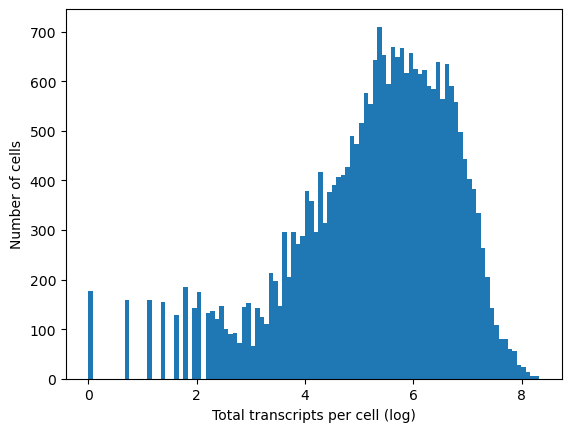

In [3]:
import matplotlib.pyplot as plt

plt.hist(np.log(T7_cbg['total transcripts']), bins=100)
plt.xlabel('Total transcripts per cell (log)')
plt.ylabel('Number of cells')
plt.show()

In [12]:
# We can set a transcript threshold here at 20 transcripts per cell based on the distrubution above
T7_filt_cbg = T7_cbg[T7_cbg['total transcripts']>19]
T7_filt_cbg_rep = T7_cbg_rep[T7_cbg_rep['total transcripts']>19]

##### *Merge the enhancer & T7 matrices based on the filtered T7 matrix*

In [13]:
merged = pd.merge(T7_filt_cbg, enhancer_cbg, how='left', left_on='masks', right_on='masks')
merged_rep = pd.merge(T7_filt_cbg_rep, enhancer_cbg_rep, how='left', left_on='masks', right_on='masks')

##### *Create new dataframes for enhancer counts and T7 counts from the merged dataframe*

In [14]:
# T7 matrix
T7_m = merged.iloc[:,1:21]
T7_m.columns = CREs
T7_m['total transcripts'] = T7_m.sum(axis=1)
T7_m['masks'] = merged['masks']
T7_m['fov'] = pd.cut(merged.masks.astype(int), bins = np.arange(0, 185)*1000, right=False)

# enhancer matrix
CRE_m = merged.iloc[:,23:43]
CRE_m.columns = CREs
CRE_m['total transcripts'] = CRE_m.sum(axis=1)
CRE_m['masks'] = merged['masks']
CRE_m['fov'] = pd.cut(merged.masks.astype(int), bins = np.arange(0, 185)*1000, right=False)

# T7 matrix
T7_m_rep = merged_rep.iloc[:,1:21]
T7_m_rep.columns = CREs
T7_m_rep['total transcripts'] = T7_m_rep.sum(axis=1)
T7_m_rep['masks'] = merged_rep['masks']
T7_m_rep['fov'] = pd.cut(merged_rep.masks.astype(int), bins = np.arange(0, 225)*1000, right=False)

# enhancer matrix
CRE_m_rep = merged_rep.iloc[:,23:43]
CRE_m_rep.columns = CREs
CRE_m_rep['total transcripts'] = CRE_m_rep.sum(axis=1)
CRE_m_rep['masks'] = merged_rep['masks']
CRE_m_rep['fov'] = pd.cut(merged_rep.masks.astype(int), bins = np.arange(0, 225)*1000, right=False)

##### *Fig. 1d-e: Transcript counts per cell*

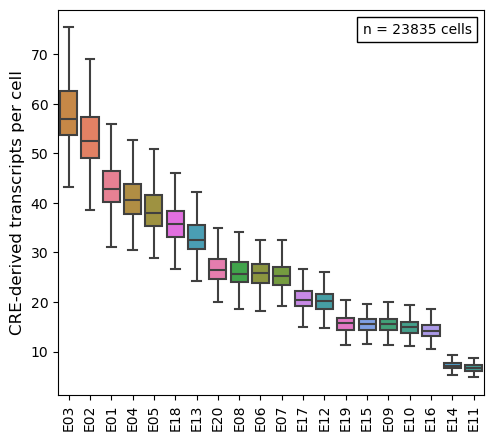

In [8]:
from matplotlib.offsetbox import AnchoredText
import seaborn as sns

x = CRE_m.groupby('fov', observed=False).mean()
sort_order = x.mean(axis=0).sort_values(ascending=False).index[2:]

fig, ax = plt.subplots(figsize=(5.5,5))
sns.boxplot([CRE_m.groupby('fov', observed=False)[i].mean() for i in CRE_m.columns[:20]],
           flierprops={"marker": "d", 'mfc' : 'gray'}, showfliers=False, linewidth=1.5,
            order=sort_order)
plt.xticks(np.arange(20), [enhancer_names[i] for i in sort_order], rotation=90);
ax.set_ylabel('CRE-derived transcripts per cell', fontsize=12)
# ax.set_title('Estimated plasmid copy number per cell')

numcells = len(CRE_m)

anchored_text = AnchoredText(f"n = {numcells} cells", loc=1)
ax.add_artist(anchored_text)

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_July_2024_analysis\T7_tpc_241003.pdf')
plt.show()

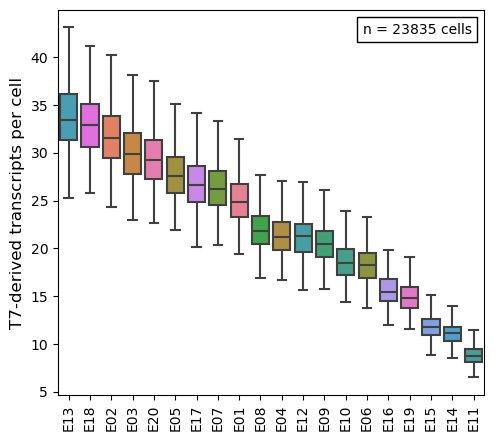

In [ ]:
x = T7_m.groupby('fov', observed=False).mean()
sort_order = x.mean(axis=0).sort_values(ascending=False).index[2:]

fig, ax = plt.subplots(figsize=(5.5,5))
sns.boxplot([T7_m.groupby('fov', observed=False)[i].mean() for i in T7_m.columns[:20]],
           flierprops={"marker": "d", 'mfc' : 'gray'}, showfliers=False, linewidth=1.5,
            order=sort_order)
plt.xticks(np.arange(20), [enhancer_names[i] for i in sort_order], rotation=90);
ax.set_ylabel('T7-derived transcripts per cell', fontsize=12)
# ax.set_title('Estimated plasmid copy number per cell')

numcells = len(T7_m)

anchored_text = AnchoredText(f"n = {numcells} cells", loc=1)
ax.add_artist(anchored_text)

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_July_2024_analysis\T7_tpc_241003.pdf')
plt.show()

##### *Fig. 1f-g: Replicate correlations for enhancer and T7 transcripts per cell*

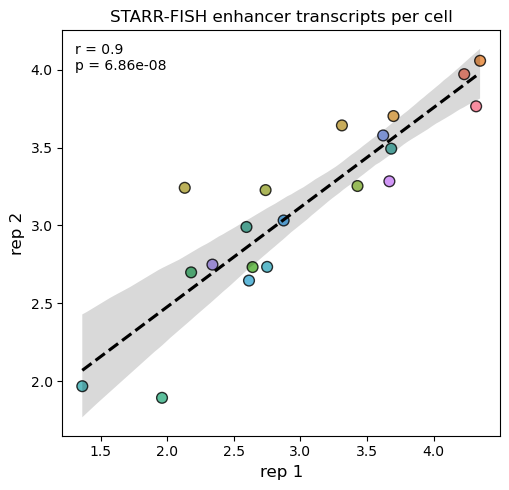

In [18]:
from matplotlib.offsetbox import AnchoredText
from scipy import stats
import seaborn as sns

fig, ax = plt.subplots(figsize=(5.2,5))

x = np.log(CRE_m_rep.iloc[:,:20].mean())
y = np.log(CRE_m.iloc[:,:20].mean())

sns.regplot(x=x, y=y,
            color='darkolivegreen',
            line_kws={'ls' : 'dashed', 'color' : 'k'},
            scatter_kws={'color' : [colors[i] for i in CRE_m.columns[:20]],
                         'linewidths' : 1, 's' : 60, 'edgecolor' : 'k'})

ax.set_xlabel('rep 1', fontsize=12)
ax.set_ylabel('rep 2', fontsize=12)
ax.set_title('STARR-FISH enhancer transcripts per cell')

# add labels to each point on the scatter plot
# for i, txt in enumerate(CRE_means.index):
#     ax.annotate(txt, (x[i], y[i]))

stats = stats.pearsonr(x, y)

corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)

anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
ax.add_artist(anchored_text)

plt.tight_layout()

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\STARR-FISH_ms_figure_1\enhancer_tpc_replicate_pearson_corr.pdf')
plt.show()

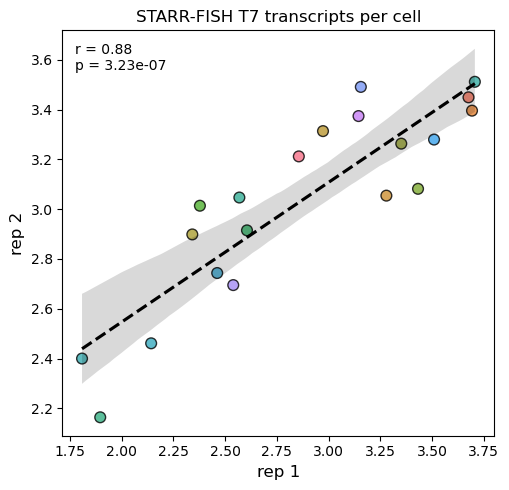

In [21]:
from matplotlib.offsetbox import AnchoredText
from scipy import stats
import seaborn as sns

fig, ax = plt.subplots(figsize=(5.2,5))

x = np.log(T7_m_rep.iloc[:,:20].mean())
y = np.log(T7_m.iloc[:,:20].mean())

sns.regplot(x=x, y=y,
            color='darkolivegreen',
            line_kws={'ls' : 'dashed', 'color' : 'k'},
            scatter_kws={'color' : [colors[i] for i in T7_m.columns[:20]],
                         'linewidths' : 1, 's' : 60, 'edgecolor' : 'k'})

ax.set_xlabel('rep 1', fontsize=12)
ax.set_ylabel('rep 2', fontsize=12)
ax.set_title('STARR-FISH T7 transcripts per cell')

# add labels to each point on the scatter plot
# for i, txt in enumerate(CRE_means.index):
#     ax.annotate(txt, (x[i], y[i]))

stats = stats.pearsonr(x, y)

corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)

anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
ax.add_artist(anchored_text)

plt.tight_layout()

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\STARR-FISH_ms_figure_1\T7_tpc_replicate_pearson_corr.pdf')
plt.show()

##### *Fig. 1i-k: Correlations between STARR-FISH and STARR-seq activity*

In [120]:
# Load in featureCounts table from bulk RNA-seq sample
RNAseq = pd.read_csv(r'C:\Users\zgibbs\analysis\zgibbs_local\bulk_sequencing\CRE20_20240716_rep1_featureCounts_output.txt', sep = '\t', header=1)
RNAseq2 = pd.read_csv(r'C:\Users\zgibbs\analysis\zgibbs_local\bulk_sequencing\CRE20_20240906_rep1_featureCounts_output.txt', sep = '\t', header=1)

# Change name of last column
RNAseq = RNAseq.rename(columns={'/tscc/projects/ps-renlab2/zgibbs/STARR-FISH/RNAseq/CRE20_20240716_rep1/dedup.aligned_reads.bam': 'Counts'})
RNAseq2 = RNAseq2.rename(columns={'/tscc/projects/ps-renlab2/zgibbs/STARR-FISH/RNAseq/CRE20_20240906_rep1/dedup.aligned_reads.bam': 'Counts'})


# Make a new column for calculated cpm of each CRE transcript
# use the total number of reads from bulk RNA-seq sample here
RNAseq['cpm'] = (RNAseq['Counts'].div(30262411))*1000000
RNAseq2['cpm'] = (RNAseq2['Counts'].div(45700375))*1000000 

# Merge glm fit results with RNA-seq data
df_merge_nanopore = pd.merge(july_experiment['glm_fit_total_result_nanopore'], RNAseq, left_index=True, right_on='Geneid')
df_merge_nanopore['RNA-seq nanopore norm'] = df_merge_nanopore['Counts'] / np.log1p(df_merge_nanopore['nanopore'])
df_merge_T7 = pd.merge(july_experiment['glm_fit_total_result_T7'], RNAseq, left_index=True, right_on='Geneid')
df_merge_T7['RNA-seq nanopore norm'] = df_merge_nanopore['RNA-seq nanopore norm']
df_merge_T7['enhancer tpc'] = july_experiment['enhancer'].iloc[:,:-1].mean(axis=0).values
df_merge_T7['T7 tpc'] = july_experiment['vector'].iloc[:,:-1].mean(axis=0).values

df_merge2_nanopore = pd.merge(sept_experiment['glm_fit_total_result_nanopore'], RNAseq2, left_index=True, right_on='Geneid')
df_merge2_nanopore['RNA-seq nanopore norm'] = df_merge2_nanopore['Counts'] / np.log1p(df_merge2_nanopore['nanopore'])
df_merge2_T7 = pd.merge(sept_experiment['glm_fit_total_result_T7'], RNAseq2, left_index=True, right_on='Geneid')
df_merge2_T7['RNA-seq nanopore norm'] = df_merge2_nanopore['RNA-seq nanopore norm']
df_merge2_T7['enhancer tpc'] = sept_experiment['enhancer'].iloc[:,:-1].mean(axis=0).values
df_merge2_T7['T7 tpc'] = sept_experiment['vector'].iloc[:,:-1].mean(axis=0).values

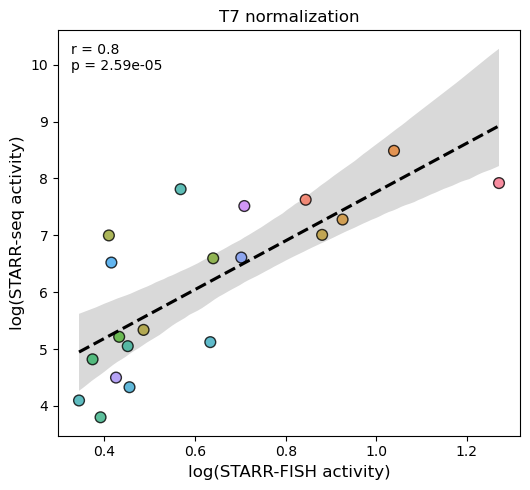

In [156]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import Divider, Size
from scipy import stats
from matplotlib.offsetbox import AnchoredText

fig, ax = plt.subplots(figsize=(5.4, 5))

keep = df_merge_nanopore['nanopore'] >= 1

x = (df_merge_T7['STARR-FISH Activity'][keep] + df_merge2_T7['STARR-FISH Activity'][keep]) / 2
y = (df_merge_nanopore['RNA-seq nanopore norm'] + df_merge2_nanopore['RNA-seq nanopore norm']) / 2

mask = np.isfinite(x) & np.isfinite(y)

x = np.log1p(x[mask])
y = np.log1p(y[mask])

sns.regplot(x=x, y=y, fit_reg=True, scatter=True,
            color='olive',
            line_kws={'ls' : 'dashed', 'color' : 'k', 'zorder' : 3},
            scatter_kws={'color' : [colors[i] for i in df_merge2_nanopore['Geneid'][keep]],
                         'linewidths' : 1, 's' : 60, 'edgecolor' : 'k', 'zorder' : 2})

ax.set_xlabel('log(STARR-FISH activity)', fontsize=12)
ax.set_ylabel('log(STARR-seq activity)', fontsize=12)
ax.set_title('T7 normalization')

stats = stats.spearmanr(x, y)
corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)
anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
ax.add_artist(anchored_text)

plt.tight_layout()
plt.show()

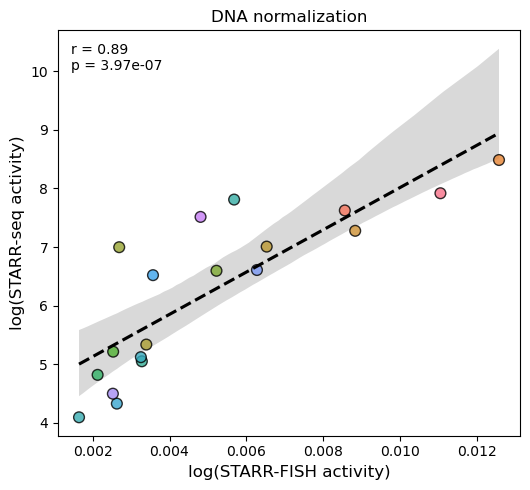

In [157]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import Divider, Size
from scipy import stats
from matplotlib.offsetbox import AnchoredText

fig, ax = plt.subplots(figsize=(5.4, 5))

keep = df_merge_nanopore['nanopore'] >= 5

x = (df_merge_nanopore['STARR-FISH Activity'][keep] + df_merge2_nanopore['STARR-FISH Activity'][keep]) / 2
y = (df_merge_nanopore['RNA-seq nanopore norm'] + df_merge2_nanopore['RNA-seq nanopore norm']) / 2

mask = np.isfinite(x) & np.isfinite(y)

x = np.log1p(x[mask])
y = np.log1p(y[mask])

sns.regplot(x=x, y=y, fit_reg=True, scatter=True,
            color='olive',
            line_kws={'ls' : 'dashed', 'color' : 'k', 'zorder' : 3},
            scatter_kws={'color' : [colors[i] for i in df_merge2_nanopore['Geneid'][keep]],
                         'linewidths' : 1, 's' : 60, 'edgecolor' : 'k', 'zorder' : 2})

ax.set_xlabel('log(STARR-FISH activity)', fontsize=12)
ax.set_ylabel('log(STARR-seq activity)', fontsize=12)
ax.set_title('DNA normalization')

stats = stats.spearmanr(x, y)
corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)
anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
ax.add_artist(anchored_text)

plt.tight_layout()
plt.show()

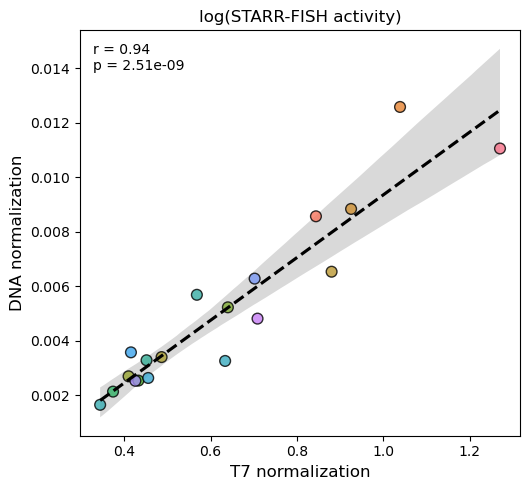

In [158]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import Divider, Size
from scipy import stats
from matplotlib.offsetbox import AnchoredText

fig, ax = plt.subplots(figsize=(5.4, 5))

keep = df_merge_nanopore['nanopore'] >= 5

x = (df_merge_T7['STARR-FISH Activity'][keep] + df_merge2_T7['STARR-FISH Activity'][keep]) / 2
y = (df_merge_nanopore['STARR-FISH Activity'][keep] + df_merge2_nanopore['STARR-FISH Activity'][keep]) / 2

mask = np.isfinite(x) & np.isfinite(y)

x = np.log1p(x[mask])
y = np.log1p(y[mask])

sns.regplot(x=x, y=y, fit_reg=True, scatter=True,
            color='olive',
            line_kws={'ls' : 'dashed', 'color' : 'k', 'zorder' : 3},
            scatter_kws={'color' : [colors[i] for i in df_merge2_nanopore['Geneid'][keep]],
                         'linewidths' : 1, 's' : 60, 'edgecolor' : 'k', 'zorder' : 2})

ax.set_xlabel('T7 normalization', fontsize=12)
ax.set_ylabel('DNA normalization', fontsize=12)
ax.set_title('log(STARR-FISH activity)')

stats = stats.pearsonr(x, y)
corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)
anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
ax.add_artist(anchored_text)

plt.tight_layout()
plt.show()

#### **2. Extended Data Fig. 1 panels**

##### *Extended Data Fig. 1b-c: Correlations between imaging counts and sequencing*

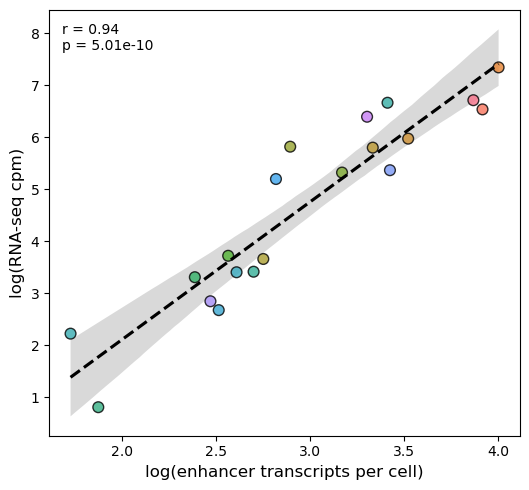

In [124]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import Divider, Size
from scipy import stats
from matplotlib.offsetbox import AnchoredText

fig, ax = plt.subplots(figsize=(5.4, 5))

keep = df_merge_nanopore['nanopore'] >= 1

x = (df_merge_T7['enhancer tpc'][keep] + df_merge2_T7['enhancer tpc'][keep]) / 2
y = (df_merge_nanopore['cpm'][keep] + df_merge2_nanopore['cpm'][keep]) / 2

mask = np.isfinite(x) & np.isfinite(y)

x = np.log1p(x[mask])
y = np.log1p(y[mask])

sns.regplot(x=x, y=y, fit_reg=True, scatter=True,
            color='olive',
            line_kws={'ls' : 'dashed', 'color' : 'k', 'zorder' : 3},
            scatter_kws={'color' : [colors[i] for i in df_merge2_nanopore['Geneid'][keep]],
                         'linewidths' : 1, 's' : 60, 'edgecolor' : 'k', 'zorder' : 2})

ax.set_xlabel('log(enhancer transcripts per cell)', fontsize=12)
ax.set_ylabel('log(RNA-seq cpm)', fontsize=12)

stats = stats.spearmanr(x, y)
corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)
anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
ax.add_artist(anchored_text)

plt.tight_layout()
plt.show()

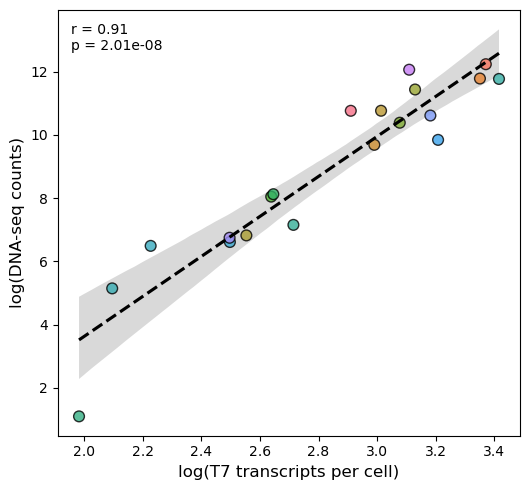

In [125]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import Divider, Size
from scipy import stats
from matplotlib.offsetbox import AnchoredText

fig, ax = plt.subplots(figsize=(5.4, 5))

keep = df_merge_nanopore['nanopore'] >= 1

x = (df_merge_T7['T7 tpc'][keep] + df_merge2_T7['T7 tpc'][keep]) / 2
y = df_merge_nanopore['nanopore'][keep]

mask = np.isfinite(x) & np.isfinite(y)

x = np.log1p(x[mask])
y = np.log1p(y[mask])

sns.regplot(x=x, y=y, fit_reg=True, scatter=True,
            color='olive',
            line_kws={'ls' : 'dashed', 'color' : 'k', 'zorder' : 3},
            scatter_kws={'color' : [colors[i] for i in df_merge2_nanopore['Geneid'][keep]],
                         'linewidths' : 1, 's' : 60, 'edgecolor' : 'k', 'zorder' : 2})

ax.set_xlabel('log(T7 transcripts per cell)', fontsize=12)
ax.set_ylabel('log(DNA-seq counts)', fontsize=12)

stats = stats.spearmanr(x, y)
corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)
anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
ax.add_artist(anchored_text)

plt.tight_layout()
plt.show()

##### *Extended Data Fig. 1d: Downsampled STARR-FISH activity plots (T7 normalization)*

In [126]:
def glm_fit_total_ds(experiment, family=sm.families.Gaussian(), subsample_size = 1000, norm_by_vector=True, norm_by_nanopore=True, use_fov_covariate=False, key_add='glm_fit_total_result'):
    # Create the model
    enhancer = experiment["enhancer"].sample(n=subsample_size, random_state=i) # subsample the enhancer data
    vector = experiment["vector"].loc[enhancer.index] # subsample the vector data to match the enhancer data
    enh_result = pd.DataFrame()
    vec_result = pd.DataFrame()
    for cre in enhancer.columns[:-1]:
        if cre not in vector.columns:
            raise ValueError(f"CRE {cre} not found in vector data.")
        fit_data=pd.DataFrame({'y': enhancer[cre].values, 
                               'x': enhancer['total transcripts'].values})
        if not use_fov_covariate:
            glm_results = smf.ols('y ~ x', fit_data, family=family).fit()
        else:
            glm_results = smf.ols('y ~ x + C(fov)', fit_data, family=family).fit()
        # Fit the model
        glm_summary = pd.read_html(glm_results.summary().tables[1].as_html(), header=0, index_col=0)[0]
        glm_summary = pd.DataFrame(glm_summary.loc['x']).T
        glm_summary.index = [cre]
        enh_result = pd.concat([enh_result, glm_summary], axis=0)
        
        fit_data=pd.DataFrame({'y': vector[cre].values, 
                               'x': vector['total transcripts'].values})
        if not use_fov_covariate:
            glm_results = smf.ols('y ~ x', fit_data, family=family).fit()
        else:
            glm_results = smf.ols('y ~ x + C(fov)', fit_data, family=family).fit()
        # Fit the model
        glm_summary = pd.read_html(glm_results.summary().tables[1].as_html(), header=0, index_col=0)[0]
        glm_summary = pd.DataFrame(glm_summary.loc['x']).T
        glm_summary.index = [cre]
        vec_result = pd.concat([vec_result, glm_summary], axis=0)
    result = enh_result.copy()
    result.index = [f'CRE{str(i+1).zfill(3)}' for i in range(len(result))]
    if norm_by_vector:
        result['coef'] = result['coef'].values / vec_result['coef'].values
    if norm_by_nanopore:
        nanopore = pd.read_csv(r'C:\Users\zgibbs\analysis\zgibbs_local\bulk_sequencing\plasmidsaurus_20250213\N5LC7G_2_sample_2_counts', sep=' ', skipinitialspace=True, header=None)
        nanopore.set_index(1, inplace=True)
        result['nanopore'] = nanopore[0].loc[result.index].values
        result['coef'] = result['coef'].values / np.log(result['nanopore'].values)

    result = result.rename(columns={'coef': 'STARR-FISH Activity', 'std err': 'STARR-FISH Activity std err'})
    experiment[key_add] = result
    return experiment

In [127]:
import pandas as pd
import numpy as np
from tqdm import tqdm

# Parameters
n_subsamples = 100  # Number of subsamples
subsample_size = 2500  # Size of each subsample

# List to store statistics for each subsample
results = []

# Subsampling loop
for i in tqdm(range(n_subsamples)):
    # Randomly sample without replacement
    subsample = glm_fit_total_ds(sept_experiment, family=sm.families.Gaussian(), subsample_size=subsample_size, norm_by_vector=True, norm_by_nanopore=False, key_add='glm_fit_total_result')
    
    # Filter out CREs with too few nanopore counts
    # keep = subsample['glm_fit_total_result']['nanopore'] >= 100

    # Calculate statistics for each column
    stats = {'subsample': i+1}  # Include the subsample number
    
    for cre in subsample['glm_fit_total_result'].index:
        # Store statistics for the cres
        stats[cre] = subsample['glm_fit_total_result'].loc[cre, 'STARR-FISH Activity']

    # Append the results for this subsample
    results.append(stats)

# Convert the results into a DataFrame
stats_df = pd.DataFrame(results)
std_dev = stats_df.iloc[:,1:].std()
avg =  stats_df.iloc[:,1:].mean()
cv = std_dev / avg

# Add final stats to dataframe

stats_df.loc['avg'] = avg
stats_df.loc['std_dev'] = std_dev
stats_df.loc['cv'] = cv
df2500 = stats_df

df2500 = df2500.sort_values('avg', axis=1, ascending=False)

100%|██████████| 100/100 [00:37<00:00,  2.68it/s]


In [128]:
# Parameters
n_subsamples = 100  # Number of subsamples
subsample_size = 500  # Size of each subsample

# List to store statistics for each subsample
results = []

# Subsampling loop
for i in tqdm(range(n_subsamples)):
    # Randomly sample without replacement
    subsample = glm_fit_total_ds(sept_experiment, family=sm.families.Gaussian(), subsample_size=subsample_size, norm_by_vector=True, norm_by_nanopore=False, key_add='glm_fit_total_result')
    
    # Filter out CREs with too few nanopore counts
    # keep = subsample['glm_fit_total_result']['nanopore'] >= 100

    # Calculate statistics for each column
    stats = {'subsample': i+1}  # Include the subsample number
    
    for cre in subsample['glm_fit_total_result'].index:
        # Store statistics for the cres
        stats[cre] = subsample['glm_fit_total_result'].loc[cre, 'STARR-FISH Activity']

    # Append the results for this subsample
    results.append(stats)

# Convert the results into a DataFrame
stats_df = pd.DataFrame(results)
std_dev = stats_df.iloc[:,1:].std()
avg =  stats_df.iloc[:,1:].mean()
cv = std_dev / avg

# Add final stats to dataframe

stats_df.loc['avg'] = avg
stats_df.loc['std_dev'] = std_dev
stats_df.loc['cv'] = cv
df500 = stats_df

df500 = df500.sort_values('avg', axis=1, ascending=False)

100%|██████████| 100/100 [00:36<00:00,  2.77it/s]


In [129]:
# Parameters
n_subsamples = 100  # Number of subsamples
subsample_size = 100  # Size of each subsample

# List to store statistics for each subsample
results = []

# Subsampling loop
for i in tqdm(range(n_subsamples)):
    # Randomly sample without replacement
    subsample = glm_fit_total_ds(sept_experiment, family=sm.families.Gaussian(), subsample_size=subsample_size, norm_by_vector=True, norm_by_nanopore=False, key_add='glm_fit_total_result')
    
    # Filter out CREs with too few nanopore counts
    # keep = subsample['glm_fit_total_result']['nanopore'] >= 100

    # Calculate statistics for each column
    stats = {'subsample': i+1}  # Include the subsample number
    
    for cre in subsample['glm_fit_total_result'].index:
        # Store statistics for the cres
        stats[cre] = subsample['glm_fit_total_result'].loc[cre, 'STARR-FISH Activity']

    # Append the results for this subsample
    results.append(stats)

# Convert the results into a DataFrame
stats_df = pd.DataFrame(results)
std_dev = stats_df.iloc[:,1:].std()
avg =  stats_df.iloc[:,1:].mean()
cv = std_dev / avg

# Add final stats to dataframe

stats_df.loc['avg'] = avg
stats_df.loc['std_dev'] = std_dev
stats_df.loc['cv'] = cv
df100 = stats_df

df100 = df100.sort_values('avg', axis=1, ascending=False)

100%|██████████| 100/100 [00:35<00:00,  2.84it/s]


In [130]:
# Parameters
n_subsamples = 100  # Number of subsamples
subsample_size = 50  # Size of each subsample

# List to store statistics for each subsample
results = []

# Subsampling loop
for i in tqdm(range(n_subsamples)):
    # Randomly sample without replacement
    subsample = glm_fit_total_ds(sept_experiment, family=sm.families.Gaussian(), subsample_size=subsample_size, norm_by_vector=True, norm_by_nanopore=False, key_add='glm_fit_total_result')
    
    # Filter out CREs with too few nanopore counts
    # keep = subsample['glm_fit_total_result']['nanopore'] >= 100

    # Calculate statistics for each column
    stats = {'subsample': i+1}  # Include the subsample number
    
    for cre in subsample['glm_fit_total_result'].index:
        # Store statistics for the cres
        stats[cre] = subsample['glm_fit_total_result'].loc[cre, 'STARR-FISH Activity']

    # Append the results for this subsample
    results.append(stats)

# Convert the results into a DataFrame
stats_df = pd.DataFrame(results)
std_dev = stats_df.iloc[:,1:].std()
avg =  stats_df.iloc[:,1:].mean()
cv = std_dev / avg

# Add final stats to dataframe

stats_df.loc['avg'] = avg
stats_df.loc['std_dev'] = std_dev
stats_df.loc['cv'] = cv
df50 = stats_df

df50 = df50.sort_values('avg', axis=1, ascending=False)

100%|██████████| 100/100 [00:35<00:00,  2.83it/s]


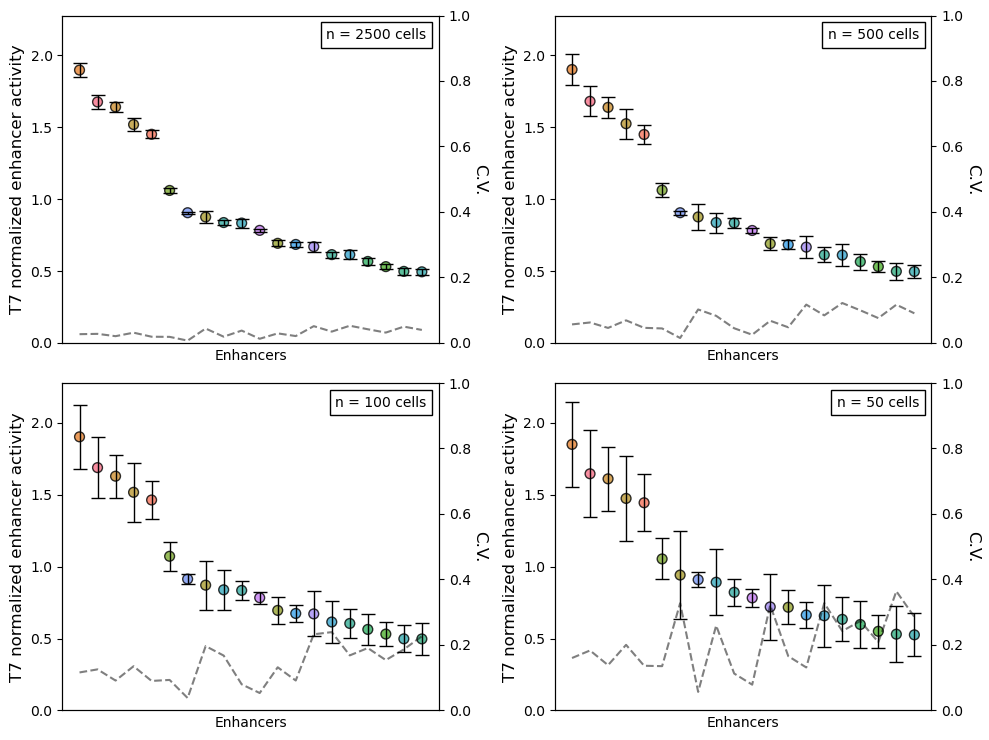

In [131]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText

# List of DataFrames and their corresponding names
dataframes = [df2500, df500, df100, df50]
df_names = ['2500 cells', '500 cells', '100 cells', '50 cells']

fig, axs = plt.subplots(2, 2, figsize=(10, 7.5))

# Loop through DataFrames and plot each
for i, (df, name) in enumerate(zip(dataframes, df_names)):
    row, col = divmod(i, 2)  # Calculate row and column index for the subplot
    ax = axs[row, col]
    
    # number of enhancers
    cre_num = dataframes[0].shape[1] - 1

    # set the ylim
    ylim = dataframes[0].iloc[-3,:-1].max() + (dataframes[0].iloc[-3,:-1].max() * 0.2)

    # Scatter plot with error bars
    ax.scatter(range(0, cre_num), df.iloc[-3,:cre_num], marker='o', c=[colors[i] for i in df.columns[:cre_num]], s=50, lw=1, edgecolor='k', alpha=0.8)
    ax.errorbar(range(0, cre_num), df.iloc[-3,:cre_num], df.iloc[-2,:cre_num], linestyle='', linewidth=1, capsize=5, mew=1, ecolor='k')
    ax.set_ylabel('T7 normalized enhancer activity', fontsize=12)
    ax.set_ylim(0, ylim)
    ax.set_xlabel('Enhancers')
    ax.set_xticks([])
    
    # Create twin axis for CV plot
    ax_twin = ax.twinx()
    ax_twin.plot(range(0, cre_num), df.iloc[-1,:cre_num], lw=1.5, c='k', linestyle='--', alpha=0.5, zorder=1)
    ax_twin.set_ylim(0, 1)
    ax_twin.set_ylabel('C.V.', fontsize=12, rotation=270, labelpad=12)
    
    # Add annotation for the number of cells
    anchored_text = AnchoredText(f"n = {name}", loc=1)
    ax.add_artist(anchored_text)

plt.tight_layout()
plt.show()

##### *Extended Data Fig. 1e: Downsampled STARR-FISH activity plots (DNA normalization)*

In [148]:
import pandas as pd
import numpy as np
from tqdm import tqdm

# Parameters
n_subsamples = 100  # Number of subsamples
subsample_size = 2500  # Size of each subsample

# List to store statistics for each subsample
results = []

# Subsampling loop
for i in tqdm(range(n_subsamples)):
    # Randomly sample without replacement
    subsample = glm_fit_total_ds(sept_experiment, family=sm.families.Gaussian(), subsample_size=subsample_size, norm_by_vector=False, norm_by_nanopore=True, key_add='glm_fit_total_result')
    
    # Filter out CREs with too few nanopore counts
    keep = subsample['glm_fit_total_result']['nanopore'] >= 5

    # Calculate statistics for each column
    stats = {'subsample': i+1}  # Include the subsample number
    
    for cre in subsample['glm_fit_total_result'][keep].index:
        # Store statistics for the cres
        stats[cre] = subsample['glm_fit_total_result'][keep].loc[cre, 'STARR-FISH Activity']

    # Append the results for this subsample
    results.append(stats)

# Convert the results into a DataFrame
stats_df = pd.DataFrame(results)
std_dev = stats_df.iloc[:,1:].std()
avg =  stats_df.iloc[:,1:].mean()
cv = std_dev / avg

# Add final stats to dataframe

stats_df.loc['avg'] = avg
stats_df.loc['std_dev'] = std_dev
stats_df.loc['cv'] = cv
df2500 = stats_df

df2500 = df2500.sort_values('avg', axis=1, ascending=False)

100%|██████████| 100/100 [00:39<00:00,  2.55it/s]


In [149]:
import pandas as pd
import numpy as np
from tqdm import tqdm

# Parameters
n_subsamples = 100  # Number of subsamples
subsample_size = 500  # Size of each subsample

# List to store statistics for each subsample
results = []

# Subsampling loop
for i in tqdm(range(n_subsamples)):
    # Randomly sample without replacement
    subsample = glm_fit_total_ds(sept_experiment, family=sm.families.Gaussian(), subsample_size=subsample_size, norm_by_vector=False, norm_by_nanopore=True, key_add='glm_fit_total_result')
    
    # Filter out CREs with too few nanopore counts
    keep = subsample['glm_fit_total_result']['nanopore'] >= 5

    # Calculate statistics for each column
    stats = {'subsample': i+1}  # Include the subsample number
    
    for cre in subsample['glm_fit_total_result'][keep].index:
        # Store statistics for the cres
        stats[cre] = subsample['glm_fit_total_result'][keep].loc[cre, 'STARR-FISH Activity']

    # Append the results for this subsample
    results.append(stats)

# Convert the results into a DataFrame
stats_df = pd.DataFrame(results)
std_dev = stats_df.iloc[:,1:].std()
avg =  stats_df.iloc[:,1:].mean()
cv = std_dev / avg

# Add final stats to dataframe

stats_df.loc['avg'] = avg
stats_df.loc['std_dev'] = std_dev
stats_df.loc['cv'] = cv
df500 = stats_df

df500 = df500.sort_values('avg', axis=1, ascending=False)

100%|██████████| 100/100 [00:35<00:00,  2.80it/s]


In [150]:
import pandas as pd
import numpy as np
from tqdm import tqdm

# Parameters
n_subsamples = 100  # Number of subsamples
subsample_size = 100  # Size of each subsample

# List to store statistics for each subsample
results = []

# Subsampling loop
for i in tqdm(range(n_subsamples)):
    # Randomly sample without replacement
    subsample = glm_fit_total_ds(sept_experiment, family=sm.families.Gaussian(), subsample_size=subsample_size, norm_by_vector=False, norm_by_nanopore=True, key_add='glm_fit_total_result')
    
    # Filter out CREs with too few nanopore counts
    keep = subsample['glm_fit_total_result']['nanopore'] >= 5

    # Calculate statistics for each column
    stats = {'subsample': i+1}  # Include the subsample number
    
    for cre in subsample['glm_fit_total_result'][keep].index:
        # Store statistics for the cres
        stats[cre] = subsample['glm_fit_total_result'][keep].loc[cre, 'STARR-FISH Activity']

    # Append the results for this subsample
    results.append(stats)

# Convert the results into a DataFrame
stats_df = pd.DataFrame(results)
std_dev = stats_df.iloc[:,1:].std()
avg =  stats_df.iloc[:,1:].mean()
cv = std_dev / avg

# Add final stats to dataframe

stats_df.loc['avg'] = avg
stats_df.loc['std_dev'] = std_dev
stats_df.loc['cv'] = cv
df100 = stats_df

df100 = df100.sort_values('avg', axis=1, ascending=False)

100%|██████████| 100/100 [00:34<00:00,  2.88it/s]


In [151]:
import pandas as pd
import numpy as np
from tqdm import tqdm

# Parameters
n_subsamples = 100  # Number of subsamples
subsample_size = 50  # Size of each subsample

# List to store statistics for each subsample
results = []

# Subsampling loop
for i in tqdm(range(n_subsamples)):
    # Randomly sample without replacement
    subsample = glm_fit_total_ds(sept_experiment, family=sm.families.Gaussian(), subsample_size=subsample_size, norm_by_vector=False, norm_by_nanopore=True, key_add='glm_fit_total_result')
    
    # Filter out CREs with too few nanopore counts
    keep = subsample['glm_fit_total_result']['nanopore'] >= 5

    # Calculate statistics for each column
    stats = {'subsample': i+1}  # Include the subsample number
    
    for cre in subsample['glm_fit_total_result'][keep].index:
        # Store statistics for the cres
        stats[cre] = subsample['glm_fit_total_result'][keep].loc[cre, 'STARR-FISH Activity']

    # Append the results for this subsample
    results.append(stats)

# Convert the results into a DataFrame
stats_df = pd.DataFrame(results)
std_dev = stats_df.iloc[:,1:].std()
avg =  stats_df.iloc[:,1:].mean()
cv = std_dev / avg

# Add final stats to dataframe

stats_df.loc['avg'] = avg
stats_df.loc['std_dev'] = std_dev
stats_df.loc['cv'] = cv
df50 = stats_df

df50 = df50.sort_values('avg', axis=1, ascending=False)

100%|██████████| 100/100 [00:34<00:00,  2.88it/s]


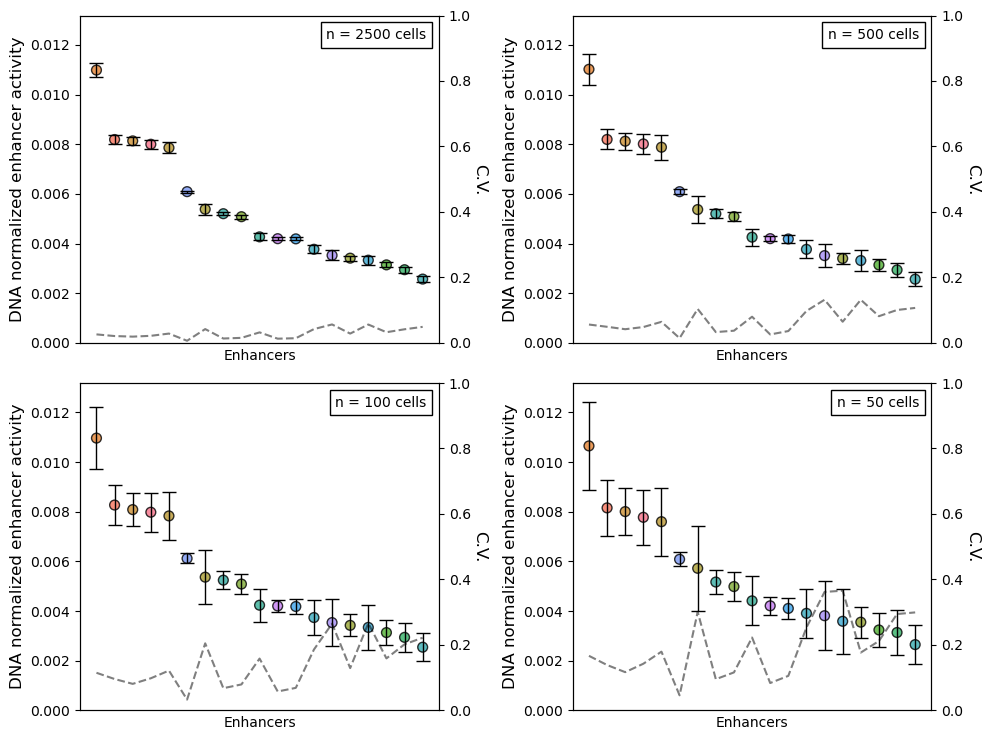

In [152]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText

# List of DataFrames and their corresponding names
dataframes = [df2500, df500, df100, df50]
df_names = ['2500 cells', '500 cells', '100 cells', '50 cells']

fig, axs = plt.subplots(2, 2, figsize=(10, 7.5))

# Loop through DataFrames and plot each
for i, (df, name) in enumerate(zip(dataframes, df_names)):
    row, col = divmod(i, 2)  # Calculate row and column index for the subplot
    ax = axs[row, col]
    
    # number of enhancers
    cre_num = dataframes[0].shape[1] - 1

    # set the ylim
    ylim = dataframes[0].iloc[-3,:-1].max() + (dataframes[0].iloc[-3,:-1].max() * 0.2)

    # Scatter plot with error bars
    ax.scatter(range(0, cre_num), df.iloc[-3,:cre_num], marker='o', c=[colors[i] for i in df.columns[:cre_num]], s=50, lw=1, edgecolor='k', alpha=0.8)
    ax.errorbar(range(0, cre_num), df.iloc[-3,:cre_num], df.iloc[-2,:cre_num], linestyle='', linewidth=1, capsize=5, mew=1, ecolor='k')
    ax.set_ylabel('DNA normalized enhancer activity', fontsize=12)
    ax.set_ylim(0, ylim)
    ax.set_xlabel('Enhancers')
    ax.set_xticks([])
    
    # Create twin axis for CV plot
    ax_twin = ax.twinx()
    ax_twin.plot(range(0, cre_num), df.iloc[-1,:cre_num], lw=1.5, c='k', linestyle='--', alpha=0.5, zorder=1)
    ax_twin.set_ylim(0, 1)
    ax_twin.set_ylabel('C.V.', fontsize=12, rotation=270, labelpad=12)
    
    # Add annotation for the number of cells
    anchored_text = AnchoredText(f"n = {name}", loc=1)
    ax.add_artist(anchored_text)

plt.tight_layout()
plt.show()